# Physiologically cleaned 27-electrode CSP neural network

This version uses the outputs of `physiological_artifact_cleaning.ipynb`:

- common-average reference,
- ICA removal of EOG-correlated components,
- residual EOG regression,
- EMG-informed trial rejection.

CSP uses all 27 scalp EEG electrodes so it can learn from the complete spatial covariance pattern. Before CSP, label-free Euclidean alignment removes each participant's mean covariance pattern.

The model is trained and evaluated through validation only. Test participants remain untouched.

## 1. Imports and fixed configuration

Separate output paths preserve the earlier 27-electrode results. The neural network still receives 12 inputs: six mu CSP log-variance features and six beta CSP log-variance features.

In [1]:
from pathlib import Path
import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy import linalg
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    confusion_matrix, f1_score, roc_auc_score,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cpu')

def find_project_data(start=Path.cwd()):
    for parent in (start.resolve(), *start.resolve().parents):
        candidate = parent / 'data' / 'processed' / 'Signals'
        if candidate.is_dir():
            return parent / 'data'
    raise FileNotFoundError('Could not locate data/processed/Signals.')

DATA_ROOT = find_project_data()
CLEANING_ROOT = DATA_ROOT / 'processed' / 'physiological_artifact_cleaning'
INDEX_PATH = CLEANING_ROOT / 'development_index_physio_clean.csv'
OUTPUT_ROOT = DATA_ROOT / 'processed' / 'csp_neural_net_physio_27'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

ALL_ELECTRODES = [
    'Fz', 'FCz', 'Cz', 'CPz', 'Pz',
    'C1', 'C3', 'C5', 'C2', 'C4', 'C6',
    'F4', 'FC2', 'FC4', 'FC6', 'CP2', 'CP4', 'CP6', 'P4',
    'F3', 'FC1', 'FC3', 'FC5', 'CP1', 'CP3', 'CP5', 'P3',
]
SELECTED_ELECTRODES = ALL_ELECTRODES.copy()
SELECTED_INDICES = np.asarray([
    ALL_ELECTRODES.index(channel) for channel in SELECTED_ELECTRODES
])
BANDS = ['mu', 'beta']
CANDIDATE_WINDOWS = [
    '0.5_to_3.0', '0.5_to_4.0', '1.0_to_4.0',
    '1.0_to_5.0', '0.5_to_5.0',
]
BAND_TUNING_NAMES = [
    'mu_7_12', 'mu_8_12', 'mu_8_13', 'mu_8_14',
    'beta_13_25', 'beta_13_30', 'beta_15_25', 'beta_15_30',
]
MU_BAND_CANDIDATES = BAND_TUNING_NAMES[:4]
BETA_BAND_CANDIDATES = BAND_TUNING_NAMES[4:]
N_FILTERS_PER_CLASS = 3
BATCH_SIZE = 128

print('Selected electrodes:', SELECTED_ELECTRODES)
print('Output:', OUTPUT_ROOT)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/aninanni/Documents/cosmos/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/aninanni/Documents/cosmos/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/Users/aninanni/Documents/cosmos/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 807, in st

Selected electrodes: ['Fz', 'FCz', 'Cz', 'CPz', 'Pz', 'C1', 'C3', 'C5', 'C2', 'C4', 'C6', 'F4', 'FC2', 'FC4', 'FC6', 'CP2', 'CP4', 'CP6', 'P4', 'F3', 'FC1', 'FC3', 'FC5', 'CP1', 'CP3', 'CP5', 'P3']
Output: /Users/aninanni/Documents/cosmos/26-the-data-miners-analysis/bci_cleaning/data/processed/csp_neural_net_physio_27


## 2. Load and participant-align the physiological-cleaning covariance matrices

Only the cleaned train and validation rows are loaded. Each saved Ledoit–Wolf covariance matrix is checked against its sample ID, label, channel order, and assigned split.

For each participant and frequency band, Euclidean alignment whitens every trial covariance by that participant's mean covariance. Labels are never used for alignment. This retains the same 27 electrodes and 12 downstream CSP features. For an unseen participant, the method requires a label-free batch of that participant's task trials to estimate the alignment reference.

In [2]:
development = pd.read_csv(INDEX_PATH)
assert set(development['split']) == {'train', 'validation'}
assert 'test' not in set(development['split'])
assert development['sample_id'].is_unique

participant_sets = {
    split: set(rows['participant'])
    for split, rows in development.groupby('split')
}
assert len(participant_sets['train']) == 55
assert len(participant_sets['validation']) == 12
assert participant_sets['train'].isdisjoint(participant_sets['validation'])

window_covariances = np.empty(
    (
        len(development), len(CANDIDATE_WINDOWS), 2,
        len(SELECTED_ELECTRODES), len(SELECTED_ELECTRODES),
    ),
    dtype=np.float32,
)
band_tuning_covariances = np.empty(
    (len(development), len(BAND_TUNING_NAMES), 27, 27), dtype=np.float32
)
y_all = development['label_id'].to_numpy(dtype=np.int64)

for relative_path, rows in development.groupby(
    'physio_covariance_relative_path', sort=True
):
    positions = rows.index.to_numpy(dtype=int)
    covariance_rows = rows['physio_covariance_row'].to_numpy(dtype=int)
    with np.load(DATA_ROOT / relative_path, allow_pickle=False) as saved:
        assert saved['electrodes'].astype(str).tolist() == ALL_ELECTRODES
        assert np.array_equal(
            saved['sample_ids'][covariance_rows].astype(str),
            rows['sample_id'].astype(str).to_numpy(),
        )
        assert np.array_equal(
            saved['labels'][covariance_rows], rows['label_id'].to_numpy()
        )
        assert saved['window_names'].astype(str).tolist() == CANDIDATE_WINDOWS
        assert saved['band_tuning_names'].astype(str).tolist() == BAND_TUNING_NAMES
        assert str(saved['covariance_estimator']) == 'Ledoit-Wolf'
        full = saved['window_ledoit_wolf_covariances'][covariance_rows]
        tuning_full = saved[
            'band_tuning_ledoit_wolf_covariances'
        ][covariance_rows]
    selected = full[:, :, :, SELECTED_INDICES, :][
        :, :, :, :, SELECTED_INDICES
    ]
    selected_trace = np.trace(selected, axis1=3, axis2=4)
    selected = selected / selected_trace[:, :, :, None, None]
    window_covariances[positions] = selected
    tuning_selected = tuning_full[:, :, SELECTED_INDICES, :][
        :, :, :, SELECTED_INDICES
    ]
    tuning_trace = np.trace(tuning_selected, axis1=2, axis2=3)
    band_tuning_covariances[positions] = (
        tuning_selected / tuning_trace[:, :, None, None]
    )

assert np.isfinite(window_covariances).all()
assert np.isfinite(band_tuning_covariances).all()
assert np.allclose(
    np.trace(window_covariances, axis1=3, axis2=4), 1.0, atol=1e-5
)

participant_array = development['participant'].to_numpy()
alignment_participants = np.asarray(sorted(development['participant'].unique()))
alignment_references = np.empty(
    (
        len(alignment_participants), len(CANDIDATE_WINDOWS),
        len(BANDS), 27, 27,
    ), dtype=np.float32
)
alignment_whiteners = np.empty_like(alignment_references)
band_alignment_references = np.empty(
    (len(alignment_participants), len(BAND_TUNING_NAMES), 27, 27),
    dtype=np.float32,
)
band_alignment_whiteners = np.empty_like(band_alignment_references)

def inverse_square_root(covariance):
    covariance = (covariance + covariance.T) / 2.0
    values, vectors = linalg.eigh(covariance)
    floor = max(float(values.max()) * 1e-10, np.finfo(float).eps)
    values = np.maximum(values, floor)
    return (vectors * (1.0 / np.sqrt(values))) @ vectors.T

for participant_number, participant in enumerate(alignment_participants):
    participant_mask = participant_array == participant
    for window_number in range(len(CANDIDATE_WINDOWS)):
        for band_number in range(len(BANDS)):
            reference = window_covariances[
                participant_mask, window_number, band_number
            ].mean(axis=0)
            whitener = inverse_square_root(reference)
            aligned = np.einsum(
                'ij,njk,kl->nil', whitener,
                window_covariances[
                    participant_mask, window_number, band_number
                ], whitener, optimize=True,
            )
            aligned = (aligned + aligned.transpose(0, 2, 1)) / 2.0
            traces = np.trace(aligned, axis1=1, axis2=2)
            window_covariances[
                participant_mask, window_number, band_number
            ] = (aligned / traces[:, None, None]).astype(np.float32)
            alignment_references[
                participant_number, window_number, band_number
            ] = reference
            alignment_whiteners[
                participant_number, window_number, band_number
            ] = whitener
    for band_number in range(len(BAND_TUNING_NAMES)):
        reference = band_tuning_covariances[
            participant_mask, band_number
        ].mean(axis=0)
        whitener = inverse_square_root(reference)
        aligned = np.einsum(
            'ij,njk,kl->nil', whitener,
            band_tuning_covariances[participant_mask, band_number],
            whitener, optimize=True,
        )
        aligned = (aligned + aligned.transpose(0, 2, 1)) / 2.0
        traces = np.trace(aligned, axis1=1, axis2=2)
        band_tuning_covariances[participant_mask, band_number] = (
            aligned / traces[:, None, None]
        ).astype(np.float32)
        band_alignment_references[participant_number, band_number] = reference
        band_alignment_whiteners[participant_number, band_number] = whitener

assert np.isfinite(window_covariances).all()
assert np.isfinite(band_tuning_covariances).all()
assert np.allclose(
    np.trace(window_covariances, axis1=3, axis2=4), 1.0, atol=1e-5
)
np.savez_compressed(
    OUTPUT_ROOT / 'participant_alignment_parameters.npz',
    participants=alignment_participants,
    bands=np.asarray(BANDS),
    windows=np.asarray(CANDIDATE_WINDOWS),
    references=alignment_references,
    inverse_square_roots=alignment_whiteners,
    band_tuning_names=np.asarray(BAND_TUNING_NAMES),
    band_references=band_alignment_references,
    band_inverse_square_roots=band_alignment_whiteners,
    method='label-free participant-wise Euclidean covariance alignment',
)
train_mask = development['split'].eq('train').to_numpy()
validation_mask = development['split'].eq('validation').to_numpy()

display(
    development.groupby('split').agg(
        participants=('participant', 'nunique'),
        trials=('sample_id', 'size'),
        left_trials=('label_id', lambda values: int((values == 0).sum())),
        right_trials=('label_id', lambda values: int((values == 1).sum())),
    ).reset_index()
)
print('Aligned window covariance shape:', window_covariances.shape)
print('Aligned band-tuning covariance shape:', band_tuning_covariances.shape)
print('Participants aligned:', len(alignment_participants))
print('Test trials loaded: 0')

,split,participants,trials,left_trials,right_trials
0,train,55,12029,6036,5993
1,validation,12,2535,1272,1263


Aligned window covariance shape: (14564, 5, 2, 27, 27)
Aligned band-tuning covariance shape: (14564, 8, 27, 27)
Participants aligned: 67
Test trials loaded: 0


## 3. Select the imagery window and fit CSP using training participants only

Five participant-held-out training folds compare 0.5–3.0, 0.5–4.0, 1.0–4.0, 1.0–5.0, and the original 0.5–5.0 second window. Validation participants are not used to choose the window.

Using the selected window, the same training folds then compare all 16 combinations of four mu boundaries (7–12, 8–12, 8–13, and 8–14 Hz) and four beta boundaries (13–25, 13–30, 15–25, and 15–30 Hz). Validation participants are not used to choose the bands.

Separate mu and beta CSP filters are then learned from the participant-aligned Ledoit–Wolf covariances for the selected window. For each class, covariance is first averaged within participant and then across participants, so every training participant has equal influence regardless of retained trial count. No OAS or additional manual CSP shrinkage is used. Three filters from each class extreme are retained per band, producing 12 features per trial.

In [3]:
def participant_balanced_class_covariance(
    covariances, labels, participants, class_id
):
    participant_means = []
    for participant in np.unique(participants):
        participant_class_mask = (
            (participants == participant) & (labels == class_id)
        )
        if participant_class_mask.any():
            participant_means.append(
                covariances[participant_class_mask].mean(axis=0)
            )
    if not participant_means:
        raise ValueError(f'No participant covariance available for class {class_id}.')
    return np.mean(participant_means, axis=0)

def fit_csp(covariances, labels, participants):
    left = participant_balanced_class_covariance(
        covariances, labels, participants, class_id=0
    )
    right = participant_balanced_class_covariance(
        covariances, labels, participants, class_id=1
    )
    eigenvalues, eigenvectors = linalg.eigh(left, left + right)
    selected = np.r_[
        np.arange(N_FILTERS_PER_CLASS),
        np.arange(len(eigenvalues) - N_FILTERS_PER_CLASS, len(eigenvalues)),
    ]
    return eigenvectors[:, selected].T, eigenvalues[selected]

def transform_csp(covariances, filters):
    variances = np.einsum(
        'kc,ncd,kd->nk', filters, covariances, filters, optimize=True
    )
    variances = np.maximum(variances, np.finfo(float).eps)
    return np.log(variances / variances.sum(axis=1, keepdims=True))

def build_csp_features(fit_mask, covariances=None):
    if covariances is None:
        covariances = all_covariances
    blocks = []
    filters_by_band = {}
    eigenvalues_by_band = {}
    for band_number, band_name in enumerate(BANDS):
        filters, eigenvalues = fit_csp(
            covariances[fit_mask, band_number], y_all[fit_mask],
            participant_array[fit_mask],
        )
        filters_by_band[band_name] = filters
        eigenvalues_by_band[band_name] = eigenvalues
        blocks.append(transform_csp(covariances[:, band_number], filters))
    raw = np.column_stack(blocks).astype(np.float32)
    mean = raw[fit_mask].mean(axis=0, dtype=np.float64).astype(np.float32)
    std = raw[fit_mask].std(axis=0, dtype=np.float64).astype(np.float32)
    assert np.all(std > 0)
    standardized = ((raw - mean) / std).astype(np.float32)
    return standardized, filters_by_band, eigenvalues_by_band, mean, std

class PhysioCleanCSPMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(12, 16), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(16, 8), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(8, 2),
        )

    def forward(self, inputs):
        return self.network(inputs)

def to_tensor(values, dtype):
    values = np.ascontiguousarray(values)
    return torch.frombuffer(memoryview(values), dtype=dtype).reshape(values.shape)

WINDOW_SELECTION_EPOCHS = 25
training_participants_for_selection = np.asarray(
    sorted(participant_sets['train'])
)
selection_rng = np.random.default_rng(SEED)
selection_fold = {
    participant: fold
    for fold, members in enumerate(
        np.array_split(
            selection_rng.permutation(training_participants_for_selection), 5
        ), start=1,
    )
    for participant in members
}
window_prediction_rows = []

for fold in range(1, 6):
    held_out = {
        participant for participant, assigned_fold in selection_fold.items()
        if assigned_fold == fold
    }
    fold_fit_mask = train_mask & ~np.isin(participant_array, list(held_out))
    fold_holdout_mask = train_mask & np.isin(participant_array, list(held_out))
    for window_number, window_name in enumerate(CANDIDATE_WINDOWS):
        X_window, _, _, _, _ = build_csp_features(
            fold_fit_mask, window_covariances[:, window_number]
        )
        generator = torch.Generator().manual_seed(SEED + fold)
        loader = DataLoader(
            TensorDataset(
                to_tensor(X_window[fold_fit_mask], torch.float32),
                to_tensor(y_all[fold_fit_mask], torch.int64),
            ),
            batch_size=BATCH_SIZE, shuffle=True, generator=generator,
        )
        torch.manual_seed(SEED + fold)
        selection_model = PhysioCleanCSPMLP()
        selection_optimizer = torch.optim.AdamW(
            selection_model.parameters(), lr=1e-3, weight_decay=1e-4
        )
        selection_loss = nn.CrossEntropyLoss()
        for _ in range(WINDOW_SELECTION_EPOCHS):
            selection_model.train()
            for batch_X, batch_y in loader:
                selection_optimizer.zero_grad(set_to_none=True)
                loss = selection_loss(selection_model(batch_X), batch_y)
                loss.backward()
                selection_optimizer.step()
        selection_model.eval()
        with torch.no_grad():
            logits = selection_model(
                to_tensor(X_window[fold_holdout_mask], torch.float32)
            )
            probabilities = torch.softmax(logits, dim=1)[:, 1].tolist()
            predictions = logits.argmax(dim=1).tolist()
        rows = development.loc[fold_holdout_mask, [
            'sample_id', 'participant', 'label_id'
        ]].copy()
        rows['probability'] = probabilities
        rows['prediction'] = predictions
        rows['window'] = window_name
        rows['fold'] = fold
        window_prediction_rows.append(rows)
    print(f'Window-selection fold {fold}/5 complete.')

window_predictions = pd.concat(window_prediction_rows, ignore_index=True)
window_summary_rows = []
for window_name, rows in window_predictions.groupby('window'):
    window_summary_rows.append({
        'window': window_name,
        'participants': rows['participant'].nunique(),
        'trials': len(rows),
        'balanced_accuracy': balanced_accuracy_score(
            rows['label_id'], rows['prediction']
        ),
        'accuracy': accuracy_score(rows['label_id'], rows['prediction']),
        'macro_f1': f1_score(
            rows['label_id'], rows['prediction'], average='macro'
        ),
        'roc_auc': roc_auc_score(rows['label_id'], rows['probability']),
    })
window_selection_summary = pd.DataFrame(window_summary_rows).sort_values(
    'balanced_accuracy', ascending=False
).reset_index(drop=True)
display(window_selection_summary)
window_selection_summary.to_csv(
    OUTPUT_ROOT / 'window_selection_training_cv.csv', index=False
)
window_predictions.to_csv(
    OUTPUT_ROOT / 'window_selection_training_predictions.csv', index=False
)
selected_window = window_selection_summary.iloc[0]['window']
selected_window_index = CANDIDATE_WINDOWS.index(selected_window)
all_covariances = window_covariances[:, selected_window_index]
print('Selected training-only window:', selected_window)

if selected_window != '0.5_to_3.0':
    raise RuntimeError(
        'Band-tuning cache was defined for 0.5–3.0 seconds, but training-only '
        f'window selection chose {selected_window}.'
    )

BAND_SELECTION_EPOCHS = 25
band_prediction_rows = []
for fold in range(1, 6):
    held_out = {
        participant for participant, assigned_fold in selection_fold.items()
        if assigned_fold == fold
    }
    fold_fit_mask = train_mask & ~np.isin(participant_array, list(held_out))
    fold_holdout_mask = train_mask & np.isin(participant_array, list(held_out))
    for mu_name in MU_BAND_CANDIDATES:
        for beta_name in BETA_BAND_CANDIDATES:
            mu_index = BAND_TUNING_NAMES.index(mu_name)
            beta_index = BAND_TUNING_NAMES.index(beta_name)
            pair_covariances = band_tuning_covariances[
                :, [mu_index, beta_index]
            ]
            X_pair, _, _, _, _ = build_csp_features(
                fold_fit_mask, pair_covariances
            )
            generator = torch.Generator().manual_seed(SEED + fold)
            loader = DataLoader(
                TensorDataset(
                    to_tensor(X_pair[fold_fit_mask], torch.float32),
                    to_tensor(y_all[fold_fit_mask], torch.int64),
                ),
                batch_size=BATCH_SIZE, shuffle=True, generator=generator,
            )
            torch.manual_seed(SEED + fold)
            band_model = PhysioCleanCSPMLP()
            band_optimizer = torch.optim.AdamW(
                band_model.parameters(), lr=1e-3, weight_decay=1e-4
            )
            band_loss = nn.CrossEntropyLoss()
            for _ in range(BAND_SELECTION_EPOCHS):
                band_model.train()
                for batch_X, batch_y in loader:
                    band_optimizer.zero_grad(set_to_none=True)
                    loss = band_loss(band_model(batch_X), batch_y)
                    loss.backward()
                    band_optimizer.step()
            band_model.eval()
            with torch.no_grad():
                logits = band_model(
                    to_tensor(X_pair[fold_holdout_mask], torch.float32)
                )
                probabilities = torch.softmax(logits, dim=1)[:, 1].tolist()
                predictions = logits.argmax(dim=1).tolist()
            rows = development.loc[fold_holdout_mask, [
                'sample_id', 'participant', 'label_id'
            ]].copy()
            rows['probability'] = probabilities
            rows['prediction'] = predictions
            rows['mu_band'] = mu_name
            rows['beta_band'] = beta_name
            rows['fold'] = fold
            band_prediction_rows.append(rows)
    print(f'Band-pair selection fold {fold}/5 complete.')

band_predictions = pd.concat(band_prediction_rows, ignore_index=True)
band_summary_rows = []
for (mu_name, beta_name), rows in band_predictions.groupby([
    'mu_band', 'beta_band'
]):
    band_summary_rows.append({
        'mu_band': mu_name,
        'beta_band': beta_name,
        'participants': rows['participant'].nunique(),
        'trials': len(rows),
        'balanced_accuracy': balanced_accuracy_score(
            rows['label_id'], rows['prediction']
        ),
        'accuracy': accuracy_score(rows['label_id'], rows['prediction']),
        'macro_f1': f1_score(
            rows['label_id'], rows['prediction'], average='macro'
        ),
        'roc_auc': roc_auc_score(rows['label_id'], rows['probability']),
    })
band_selection_summary = pd.DataFrame(band_summary_rows).sort_values(
    'balanced_accuracy', ascending=False
).reset_index(drop=True)
display(band_selection_summary)
band_selection_summary.to_csv(
    OUTPUT_ROOT / 'band_pair_selection_training_cv.csv', index=False
)
band_predictions.to_csv(
    OUTPUT_ROOT / 'band_pair_selection_training_predictions.csv', index=False
)
BAND_MINIMUM_CV_IMPROVEMENT = 0.002
best_band_row = band_selection_summary.iloc[0]
original_band_row = band_selection_summary.loc[
    band_selection_summary['mu_band'].eq('mu_8_13')
    & band_selection_summary['beta_band'].eq('beta_13_30')
].iloc[0]
band_cv_improvement = (
    best_band_row['balanced_accuracy']
    - original_band_row['balanced_accuracy']
)
if band_cv_improvement >= BAND_MINIMUM_CV_IMPROVEMENT:
    selected_band_row = best_band_row
    band_selection_reason = 'candidate exceeded minimum CV improvement'
else:
    selected_band_row = original_band_row
    band_selection_reason = 'best candidate was practically tied; retained original bands'
selected_mu_band = selected_band_row['mu_band']
selected_beta_band = selected_band_row['beta_band']
selected_band_indices = [
    BAND_TUNING_NAMES.index(selected_mu_band),
    BAND_TUNING_NAMES.index(selected_beta_band),
]
all_covariances = band_tuning_covariances[:, selected_band_indices]
print('Selected training-only bands:', selected_mu_band, selected_beta_band)
print('Band-selection reason:', band_selection_reason)
pd.DataFrame([{
    'best_candidate_mu': best_band_row['mu_band'],
    'best_candidate_beta': best_band_row['beta_band'],
    'best_candidate_balanced_accuracy': best_band_row['balanced_accuracy'],
    'original_balanced_accuracy': original_band_row['balanced_accuracy'],
    'cv_improvement': band_cv_improvement,
    'minimum_required_improvement': BAND_MINIMUM_CV_IMPROVEMENT,
    'selected_mu': selected_mu_band,
    'selected_beta': selected_beta_band,
    'reason': band_selection_reason,
}]).to_csv(OUTPUT_ROOT / 'band_pair_selection_decision.csv', index=False)

X_all, csp_filters, csp_eigenvalues, feature_mean, feature_std = (
    build_csp_features(train_mask)
)
FEATURE_NAMES = (
    [f'mu_csp_{number + 1}' for number in range(6)]
    + [f'beta_csp_{number + 1}' for number in range(6)]
)

feature_table = pd.DataFrame({
    'input_position': np.arange(1, 13),
    'feature_name': FEATURE_NAMES,
    'band': ['mu'] * 6 + ['beta'] * 6,
    'source_electrodes': ['|'.join(SELECTED_ELECTRODES)] * 12,
})
display(feature_table)

np.savez_compressed(
    OUTPUT_ROOT / 'csp_train_only_parameters.npz',
    mu_filters=csp_filters['mu'],
    beta_filters=csp_filters['beta'],
    mu_eigenvalues=csp_eigenvalues['mu'],
    beta_eigenvalues=csp_eigenvalues['beta'],
    feature_mean=feature_mean,
    feature_std=feature_std,
    feature_names=np.asarray(FEATURE_NAMES),
    selected_electrodes=np.asarray(SELECTED_ELECTRODES),
    selected_window=np.asarray(selected_window),
    covariance_estimator=np.asarray('Ledoit-Wolf'),
    participant_balanced_csp=np.asarray(True),
    selected_mu_band=np.asarray(selected_mu_band),
    selected_beta_band=np.asarray(selected_beta_band),
    band_selection_reason=np.asarray(band_selection_reason),
    training_participants=np.asarray(sorted(participant_sets['train'])),
)
print('CSP features:', X_all.shape)

Window-selection fold 1/5 complete.


Window-selection fold 2/5 complete.


Window-selection fold 3/5 complete.


Window-selection fold 4/5 complete.


Window-selection fold 5/5 complete.


...

Band-pair selection fold 5/5 complete.


,mu_band,beta_band,participants,trials,balanced_accuracy,accuracy,macro_f1,roc_auc
0,mu_8_14,beta_13_30,55,12029,0.691489,0.691496,0.691490,0.768896
1,mu_8_13,beta_13_30,55,12029,0.691326,0.691329,0.691326,0.765044
2,mu_8_14,beta_15_30,55,12029,0.690743,0.690747,0.690743,0.768271
3,mu_8_14,beta_15_25,55,12029,0.689677,0.689667,0.689667,0.765598
4,mu_8_14,beta_13_25,55,12029,0.688754,0.688752,0.688751,0.766090
5,mu_8_13,beta_15_30,55,12029,0.688584,0.688586,0.688583,0.763984
6,mu_8_13,beta_13_25,55,12029,0.687501,0.687505,0.687501,0.761936
7,mu_8_12,beta_13_30,55,12029,0.683177,0.683182,0.683178,0.752802
8,mu_8_13,beta_15_25,55,12029,0.681611,0.681603,0.681603,0.760121
9,mu_7_12,beta_13_30,55,12029,0.681021,0.681021,0.681019,0.747880


Selected training-only bands: mu_8_13 beta_13_30
Band-selection reason: best candidate was practically tied; retained original bands


,input_position,feature_name,band,source_electrodes
0,1,mu_csp_1,mu,Fz|FCz|Cz|CPz|Pz|C1|C3|C5|C2|C4|C6|F4|FC2|FC4|...
1,2,mu_csp_2,mu,Fz|FCz|Cz|CPz|Pz|C1|C3|C5|C2|C4|C6|F4|FC2|FC4|...
2,3,mu_csp_3,mu,Fz|FCz|Cz|CPz|Pz|C1|C3|C5|C2|C4|C6|F4|FC2|FC4|...
3,4,mu_csp_4,mu,Fz|FCz|Cz|CPz|Pz|C1|C3|C5|C2|C4|C6|F4|FC2|FC4|...
4,5,mu_csp_5,mu,Fz|FCz|Cz|CPz|Pz|C1|C3|C5|C2|C4|C6|F4|FC2|FC4|...
5,6,mu_csp_6,mu,Fz|FCz|Cz|CPz|Pz|C1|C3|C5|C2|C4|C6|F4|FC2|FC4|...
6,7,beta_csp_1,beta,Fz|FCz|Cz|CPz|Pz|C1|C3|C5|C2|C4|C6|F4|FC2|FC4|...
7,8,beta_csp_2,beta,Fz|FCz|Cz|CPz|Pz|C1|C3|C5|C2|C4|C6|F4|FC2|FC4|...
8,9,beta_csp_3,beta,Fz|FCz|Cz|CPz|Pz|C1|C3|C5|C2|C4|C6|F4|FC2|FC4|...
9,10,beta_csp_4,beta,Fz|FCz|Cz|CPz|Pz|C1|C3|C5|C2|C4|C6|F4|FC2|FC4|...


CSP features: (14564, 12)


## 4. Define and train the 27-electrode CSP MLP

The architecture remains small because CSP has already compressed the spatial information:

`12 inputs → 16 hidden units → 8 hidden units → 2 class logits`

Early stopping restores the epoch with the lowest validation loss. Test data are not used.

In [4]:
X_train = to_tensor(X_all[train_mask], torch.float32)
X_validation = to_tensor(X_all[validation_mask], torch.float32)
y_train = to_tensor(y_all[train_mask], torch.int64)
y_validation = to_tensor(y_all[validation_mask], torch.int64)

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    TensorDataset(X_train, y_train), batch_size=BATCH_SIZE,
    shuffle=True, generator=generator,
)
validation_loader = DataLoader(
    TensorDataset(X_validation, y_validation),
    batch_size=BATCH_SIZE, shuffle=False,
)

loss_function = nn.CrossEntropyLoss()
torch.manual_seed(SEED)
model = PhysioCleanCSPMLP().to(DEVICE)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-3, weight_decay=1e-4
)
MAX_EPOCHS = 100
PATIENCE = 12
MIN_IMPROVEMENT = 1e-4

@torch.no_grad()
def evaluate(model_to_evaluate, loader):
    model_to_evaluate.eval()
    targets, predictions, probabilities = [], [], []
    loss_total = 0.0
    for batch_X, batch_y in loader:
        logits = model_to_evaluate(batch_X)
        loss_total += loss_function(logits, batch_y).item() * len(batch_X)
        targets.extend(batch_y.tolist())
        predictions.extend(logits.argmax(dim=1).tolist())
        probabilities.extend(torch.softmax(logits, dim=1)[:, 1].tolist())
    return (
        np.asarray(targets), np.asarray(predictions), np.asarray(probabilities),
        loss_total / len(loader.dataset),
    )

history_rows = []
best_state = None
best_epoch = 0
best_validation_loss = np.inf
epochs_without_improvement = 0
started = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    training_loss_total = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad(set_to_none=True)
        logits = model(batch_X)
        loss = loss_function(logits, batch_y)
        loss.backward()
        optimizer.step()
        training_loss_total += loss.item() * len(batch_X)
    training_loss = training_loss_total / len(train_loader.dataset)
    validation_epoch = evaluate(model, validation_loader)
    history_rows.append({
        'epoch': epoch,
        'training_loss': training_loss,
        'validation_loss': validation_epoch[3],
        'validation_balanced_accuracy': balanced_accuracy_score(
            validation_epoch[0], validation_epoch[1]
        ),
        'validation_roc_auc': roc_auc_score(
            validation_epoch[0], validation_epoch[2]
        ),
    })
    if validation_epoch[3] < best_validation_loss - MIN_IMPROVEMENT:
        best_validation_loss = validation_epoch[3]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    if epoch == 1 or epoch % 5 == 0 or epochs_without_improvement >= PATIENCE:
        print(
            f'Epoch {epoch:>3}: train loss={training_loss:.4f}; '
            f'validation loss={validation_epoch[3]:.4f}; '
            f'balanced accuracy={history_rows[-1]["validation_balanced_accuracy"]:.3f}'
        )
    if epochs_without_improvement >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

model.load_state_dict(best_state)
training_result = evaluate(model, train_loader)
validation_result = evaluate(model, validation_loader)

def metric_row(split, result):
    targets, predictions, probabilities, loss = result
    matrix = confusion_matrix(targets, predictions, labels=[0, 1])
    return {
        'split': split,
        'participants': len(participant_sets[split]),
        'trials': len(targets),
        'loss': loss,
        'accuracy': accuracy_score(targets, predictions),
        'balanced_accuracy': balanced_accuracy_score(targets, predictions),
        'macro_f1': f1_score(targets, predictions, average='macro'),
        'roc_auc': roc_auc_score(targets, probabilities),
        'cohen_kappa': cohen_kappa_score(targets, predictions),
        'true_left_pred_left': int(matrix[0, 0]),
        'true_left_pred_right': int(matrix[0, 1]),
        'true_right_pred_left': int(matrix[1, 0]),
        'true_right_pred_right': int(matrix[1, 1]),
    }

metrics = pd.DataFrame([
    metric_row('train', training_result),
    metric_row('validation', validation_result),
])
display(metrics)

pd.DataFrame(history_rows).to_csv(
    OUTPUT_ROOT / 'training_history.csv', index=False
)
metrics.to_csv(OUTPUT_ROOT / 'training_validation_metrics.csv', index=False)

before_band_tuning_path = (
    OUTPUT_ROOT / 'training_validation_metrics_before_band_tuning.csv'
)
if before_band_tuning_path.is_file():
    before_band_validation = pd.read_csv(before_band_tuning_path).query(
        "split == 'validation'"
    ).iloc[0]
    tuned_band_validation = metrics.query("split == 'validation'").iloc[0]
    band_tuning_comparison = pd.DataFrame([
        {
            'method': 'original_8_13_and_13_30',
            'balanced_accuracy': before_band_validation['balanced_accuracy'],
            'accuracy': before_band_validation['accuracy'],
            'macro_f1': before_band_validation['macro_f1'],
            'roc_auc': before_band_validation['roc_auc'],
        },
        {
            'method': f'tuned_{selected_mu_band}_and_{selected_beta_band}',
            'balanced_accuracy': tuned_band_validation['balanced_accuracy'],
            'accuracy': tuned_band_validation['accuracy'],
            'macro_f1': tuned_band_validation['macro_f1'],
            'roc_auc': tuned_band_validation['roc_auc'],
        },
    ])
    display(band_tuning_comparison)
    band_tuning_comparison.to_csv(
        OUTPUT_ROOT / 'band_tuning_validation_comparison.csv',
        index=False,
    )

torch.save({
    'model_state_dict': model.state_dict(),
    'architecture': '12 -> 16 -> 8 -> 2',
    'selected_electrodes': SELECTED_ELECTRODES,
    'cleaning': 'CAR -> ICA EOG -> residual EOG regression -> EMG rejection',
    'alignment': 'label-free participant-wise Euclidean covariance alignment',
    'selected_window': selected_window,
    'covariance_estimator': 'Ledoit-Wolf',
    'participant_balanced_csp': True,
    'selected_mu_band': selected_mu_band,
    'selected_beta_band': selected_beta_band,
    'best_epoch': best_epoch,
    'trained': True,
    'tested': False,
    'seed': SEED,
}, OUTPUT_ROOT / 'trained_physio_clean_27_electrode_csp_mlp.pt')

print('Best epoch:', best_epoch)
print(f'Training duration: {time.perf_counter() - started:.1f} seconds')
print('Test split evaluated: NO')

Epoch   1: train loss=0.6545; validation loss=0.6375; balanced accuracy=0.647


Epoch   5: train loss=0.5750; validation loss=0.6051; balanced accuracy=0.658


Epoch  10: train loss=0.5682; validation loss=0.6029; balanced accuracy=0.653


Epoch  15: train loss=0.5660; validation loss=0.6013; balanced accuracy=0.654


Epoch  20: train loss=0.5647; validation loss=0.6002; balanced accuracy=0.655


...

Epoch  55: train loss=0.5565; validation loss=0.5993; balanced accuracy=0.665


Epoch  60: train loss=0.5592; validation loss=0.5991; balanced accuracy=0.668
Early stopping at epoch 60.


,split,participants,trials,loss,accuracy,balanced_accuracy,macro_f1,roc_auc,cohen_kappa,true_left_pred_left,true_left_pred_right,true_right_pred_left,true_right_pred_right
0,train,55,12029,0.551171,0.704547,0.704495,0.704460,0.785895,0.409030,4341,1695,1859,4134
1,validation,12,2535,0.599018,0.664300,0.664202,0.663998,0.730874,0.328465,880,392,459,804


,method,balanced_accuracy,accuracy,macro_f1,roc_auc
0,original_8_13_and_13_30,0.664202,0.6643,0.663998,0.730874
1,tuned_mu_8_13_and_beta_13_30,0.664202,0.6643,0.663998,0.730874


Best epoch: 48
Training duration: 4.2 seconds
Test split evaluated: NO


## 5. Participant-level validation accuracy and behavioral comparison

Behavioral accuracy is the strict mean of `Perf_RUN_3` through `Perf_RUN_6`. It is joined after prediction and is never supplied to CSP or the MLP.

In [5]:
validation_rows = development.loc[validation_mask, [
    'sample_id', 'participant', 'label_id'
]].reset_index(drop=True)
validation_rows['predicted_label_id'] = validation_result[1]

performance_columns = ['Perf_RUN_3', 'Perf_RUN_4', 'Perf_RUN_5', 'Perf_RUN_6']
performance = pd.read_csv(
    DATA_ROOT / 'processed' / 'Perfomances.csv',
    sep=';', skiprows=2,
)
performance[performance_columns] = performance[performance_columns].apply(
    lambda values: pd.to_numeric(
        values.astype(str).str.replace(',', '.', regex=False), errors='coerce'
    )
)
performance = performance.loc[
    performance['SUJ_ID'].astype(str).str.fullmatch(r'[ABC]\d+')
].copy()
performance['aggregate_mean_performance_accuracy'] = performance[
    performance_columns
].mean(axis=1, skipna=False)
performance['performance_runs_available'] = performance[
    performance_columns
].notna().sum(axis=1)
participant_performance = performance[[
    'SUJ_ID', 'aggregate_mean_performance_accuracy', 'performance_runs_available'
]].rename(columns={'SUJ_ID': 'participant'})

participant_rows = []
for participant, rows in validation_rows.groupby('participant'):
    participant_rows.append({
        'participant': participant,
        'trials': len(rows),
        'mlp_accuracy': accuracy_score(
            rows['label_id'], rows['predicted_label_id']
        ),
        'mlp_balanced_accuracy': balanced_accuracy_score(
            rows['label_id'], rows['predicted_label_id']
        ),
    })
validation_participant_metrics = pd.DataFrame(participant_rows).merge(
    participant_performance, on='participant', how='left', validate='one_to_one'
).sort_values('mlp_balanced_accuracy', ascending=False)
validation_participant_metrics.to_csv(
    OUTPUT_ROOT / 'validation_per_participant_metrics.csv', index=False
)
display(validation_participant_metrics)

,participant,trials,mlp_accuracy,mlp_balanced_accuracy,aggregate_mean_performance_accuracy,performance_runs_available
0,A1,180,0.833333,0.832406,84.375,4
8,B65,230,0.826087,0.825515,82.500,4
1,A20,207,0.806763,0.806432,83.125,4
7,A52,239,0.786611,0.786450,88.750,4
2,A21,155,0.748387,0.752941,56.875,4
4,A31,232,0.668103,0.667670,52.500,4
9,B66,224,0.638393,0.639314,58.750,4
6,A48,146,0.616438,0.613688,56.625,4
3,A28,230,0.573913,0.574108,48.125,4
5,A45,234,0.525641,0.525641,54.375,4


## 6. Held-out accuracy for all 55 training participants

Five-fold participant cross-validation creates an out-of-fold prediction for every training trial. CSP, scaling, and MLP weights are refitted without the held-out fold. These 55 estimates are then combined with the 12 validation estimates, giving 67 non-overlapping participant accuracy rows.

In [6]:
training_participants = np.asarray(sorted(participant_sets['train']))
rng = np.random.default_rng(SEED)
fold_assignment = {
    participant: fold
    for fold, members in enumerate(
        np.array_split(rng.permutation(training_participants), 5), start=1
    )
    for participant in members
}
participant_array = development['participant'].to_numpy()
CV_EPOCHS = best_epoch
oof_frames = []

@torch.no_grad()
def predict_labels(fold_model, X, mask):
    loader = DataLoader(
        TensorDataset(
            to_tensor(X[mask], torch.float32),
            to_tensor(y_all[mask], torch.int64),
        ),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    fold_model.eval()
    predictions = []
    for batch_X, _ in loader:
        predictions.extend(fold_model(batch_X).argmax(dim=1).tolist())
    return np.asarray(predictions)

for fold in range(1, 6):
    held_out = {
        participant for participant, assigned in fold_assignment.items()
        if assigned == fold
    }
    holdout_mask = train_mask & np.isin(participant_array, list(held_out))
    fit_mask = train_mask & ~holdout_mask
    assert set(participant_array[fit_mask]).isdisjoint(held_out)

    X_fold, _, _, _, _ = build_csp_features(fit_mask)
    fold_generator = torch.Generator().manual_seed(SEED + fold)
    fold_loader = DataLoader(
        TensorDataset(
            to_tensor(X_fold[fit_mask], torch.float32),
            to_tensor(y_all[fit_mask], torch.int64),
        ),
        batch_size=BATCH_SIZE, shuffle=True, generator=fold_generator,
    )
    torch.manual_seed(SEED + fold)
    fold_model = PhysioCleanCSPMLP()
    fold_optimizer = torch.optim.AdamW(
        fold_model.parameters(), lr=1e-3, weight_decay=1e-4
    )
    for _ in range(CV_EPOCHS):
        fold_model.train()
        for batch_X, batch_y in fold_loader:
            fold_optimizer.zero_grad(set_to_none=True)
            fold_loss = loss_function(fold_model(batch_X), batch_y)
            fold_loss.backward()
            fold_optimizer.step()

    predictions = predict_labels(fold_model, X_fold, holdout_mask)
    rows = development.loc[holdout_mask, [
        'sample_id', 'participant', 'label_id'
    ]].reset_index(drop=True)
    rows['predicted_label_id'] = predictions
    rows['fold'] = fold
    oof_frames.append(rows)
    print(f'Fold {fold}: {len(held_out)} participants, {len(rows):,} trials')

training_oof = pd.concat(oof_frames, ignore_index=True)
assert training_oof['sample_id'].is_unique
assert len(training_oof) == int(train_mask.sum())
training_oof_metrics = pd.DataFrame([{
    'participants': training_oof['participant'].nunique(),
    'trials': len(training_oof),
    'accuracy': accuracy_score(
        training_oof['label_id'], training_oof['predicted_label_id']
    ),
    'balanced_accuracy': balanced_accuracy_score(
        training_oof['label_id'], training_oof['predicted_label_id']
    ),
    'macro_f1': f1_score(
        training_oof['label_id'], training_oof['predicted_label_id'],
        average='macro',
    ),
}])
training_oof.to_csv(OUTPUT_ROOT / 'training_oof_predictions.csv', index=False)
training_oof_metrics.to_csv(
    OUTPUT_ROOT / 'training_oof_metrics.csv', index=False
)
display(training_oof_metrics)

training_participant_rows = []
for participant, rows in training_oof.groupby('participant'):
    training_participant_rows.append({
        'participant': participant,
        'trials': len(rows),
        'mlp_accuracy': accuracy_score(
            rows['label_id'], rows['predicted_label_id']
        ),
        'mlp_balanced_accuracy': balanced_accuracy_score(
            rows['label_id'], rows['predicted_label_id']
        ),
        'evaluation_source': 'training participant held out by cross-validation',
    })
training_participant_metrics = pd.DataFrame(training_participant_rows).merge(
    participant_performance, on='participant', how='left', validate='one_to_one'
)
validation_for_all = validation_participant_metrics.copy()
validation_for_all['evaluation_source'] = 'validation participant'

all_participant_accuracy = pd.concat(
    [training_participant_metrics, validation_for_all], ignore_index=True
).sort_values('mlp_balanced_accuracy', ascending=False).reset_index(drop=True)
assert len(all_participant_accuracy) == 67
assert all_participant_accuracy['participant'].is_unique
assert set(training_participant_metrics['participant']).isdisjoint(
    validation_for_all['participant']
)
all_participant_accuracy.to_csv(
    OUTPUT_ROOT / 'all_67_participant_held_out_accuracy.csv', index=False
)
display(all_participant_accuracy)

Fold 1: 11 participants, 2,115 trials


Fold 2: 11 participants, 2,501 trials


Fold 3: 11 participants, 2,492 trials


Fold 4: 11 participants, 2,395 trials


Fold 5: 11 participants, 2,526 trials


,participants,trials,accuracy,balanced_accuracy,macro_f1
0,55,12029,0.690997,0.690993,0.690993


,participant,trials,mlp_accuracy,mlp_balanced_accuracy,evaluation_source,aggregate_mean_performance_accuracy,performance_runs_available
0,A56,235,0.991489,0.991489,training participant held out by cross-validation,99.375,4
1,A24,222,0.954955,0.954951,training participant held out by cross-validation,93.125,4
2,B73,220,0.936364,0.936012,training participant held out by cross-validation,86.250,4
3,B76,232,0.926724,0.926724,training participant held out by cross-validation,80.625,4
4,A25,239,0.920502,0.920413,training participant held out by cross-validation,81.250,4
...,...,...,...,...,...,...,...
62,B67,235,0.493617,0.493698,training participant held out by cross-validation,51.875,4
63,A30,231,0.489177,0.490250,training participant held out by cross-validation,40.625,4
64,B77,236,0.487288,0.487718,validation participant,53.750,4
65,A27,227,0.466960,0.466892,training participant held out by cross-validation,45.625,4


## 7. Distribution of balanced accuracy across all 67 participants

Every value is based on held-out predictions: training participants use participant-level cross-validation, while validation participants use the separately trained development model. The dashed gray line marks 50% chance performance; the solid lines mark the participant mean and median.

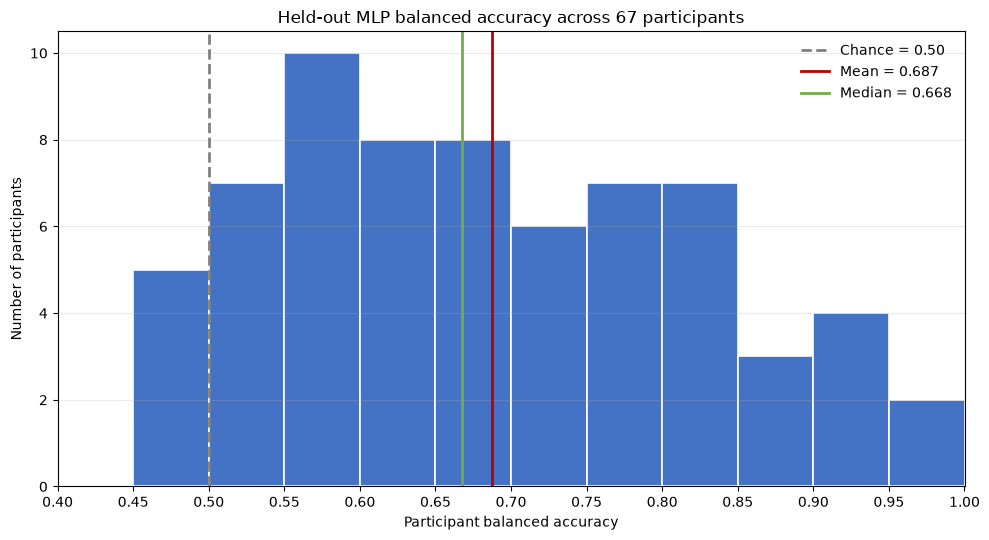

,participants,mean_balanced_accuracy,median_balanced_accuracy,standard_deviation,minimum,maximum,participants_above_chance
0,67,0.687311,0.66767,0.136434,0.464586,0.991489,62


Saved histogram: /Users/aninanni/Documents/cosmos/26-the-data-miners-analysis/bci_cleaning/data/processed/csp_neural_net_physio_27/all_67_participant_balanced_accuracy_histogram.png


In [7]:
participant_balanced_accuracy = all_participant_accuracy[
    'mlp_balanced_accuracy'
].to_numpy(dtype=float)
participant_mean = participant_balanced_accuracy.mean()
participant_median = np.median(participant_balanced_accuracy)

fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.arange(0.40, 1.001, 0.05)
ax.hist(
    participant_balanced_accuracy,
    bins=bins,
    color='#4472C4',
    edgecolor='white',
    linewidth=1.2,
)
ax.axvline(
    0.50, color='gray', linestyle='--', linewidth=2,
    label='Chance = 0.50',
)
ax.axvline(
    participant_mean, color='#C00000', linewidth=2,
    label=f'Mean = {participant_mean:.3f}',
)
ax.axvline(
    participant_median, color='#70AD47', linewidth=2,
    label=f'Median = {participant_median:.3f}',
)
ax.set(
    title='Held-out MLP balanced accuracy across 67 participants',
    xlabel='Participant balanced accuracy',
    ylabel='Number of participants',
    xlim=(0.40, 1.00),
)
ax.set_xticks(np.arange(0.40, 1.01, 0.05))
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()

histogram_path = OUTPUT_ROOT / 'all_67_participant_balanced_accuracy_histogram.png'
fig.savefig(histogram_path, dpi=300, bbox_inches='tight')
plt.show()

participant_accuracy_distribution = pd.DataFrame([{
    'participants': len(participant_balanced_accuracy),
    'mean_balanced_accuracy': participant_mean,
    'median_balanced_accuracy': participant_median,
    'standard_deviation': participant_balanced_accuracy.std(ddof=1),
    'minimum': participant_balanced_accuracy.min(),
    'maximum': participant_balanced_accuracy.max(),
    'participants_above_chance': int((participant_balanced_accuracy > 0.50).sum()),
}])
participant_accuracy_distribution.to_csv(
    OUTPUT_ROOT / 'all_67_participant_balanced_accuracy_distribution.csv',
    index=False,
)
display(participant_accuracy_distribution)
print('Saved histogram:', histogram_path)

## 8. Distribution of behavioral performance accuracy

This repeats the same histogram design for the strict mean of `Perf_RUN_3` through `Perf_RUN_6`. Behavioral percentages are divided by 100 so this plot uses the same 0–1 scale, 0.05-wide bins, and axis limits as the MLP balanced-accuracy histogram. One participant without all four behavioral runs is excluded.

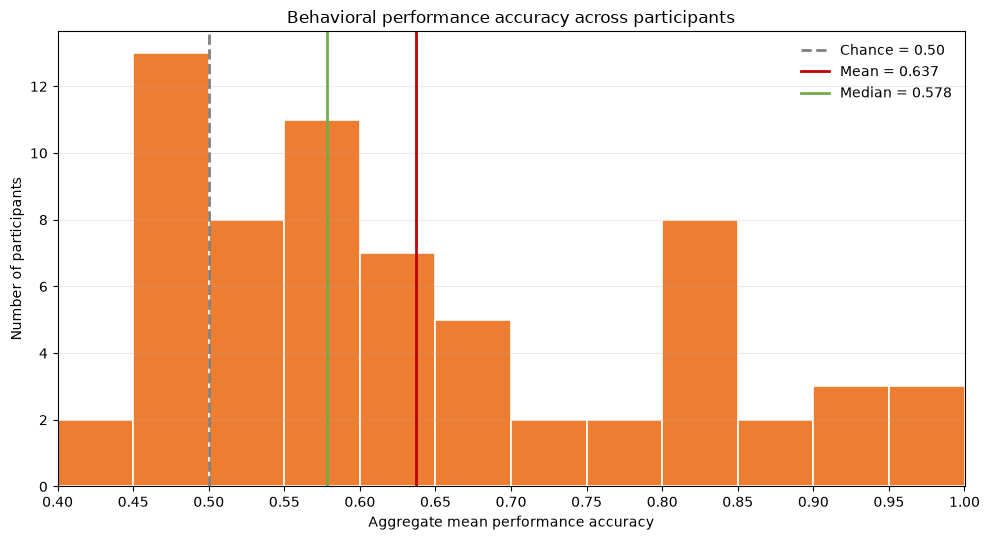

,participants,participants_missing_behavioral_accuracy,mean_behavioral_performance_accuracy,median_behavioral_performance_accuracy,standard_deviation,minimum,maximum,participants_above_chance
0,66,1,0.637392,0.578125,0.158004,0.40625,0.99375,50


Saved histogram: /Users/aninanni/Documents/cosmos/26-the-data-miners-analysis/bci_cleaning/data/processed/csp_neural_net_physio_27/all_participant_behavioral_performance_accuracy_histogram.png


In [8]:
behavioral_performance_accuracy = (
    all_participant_accuracy['aggregate_mean_performance_accuracy']
    .dropna()
    .to_numpy(dtype=float)
    / 100.0
)
behavioral_mean = behavioral_performance_accuracy.mean()
behavioral_median = np.median(behavioral_performance_accuracy)

fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.arange(0.40, 1.001, 0.05)
ax.hist(
    behavioral_performance_accuracy,
    bins=bins,
    color='#ED7D31',
    edgecolor='white',
    linewidth=1.2,
)
ax.axvline(
    0.50, color='gray', linestyle='--', linewidth=2,
    label='Chance = 0.50',
)
ax.axvline(
    behavioral_mean, color='#C00000', linewidth=2,
    label=f'Mean = {behavioral_mean:.3f}',
)
ax.axvline(
    behavioral_median, color='#70AD47', linewidth=2,
    label=f'Median = {behavioral_median:.3f}',
)
ax.set(
    title='Behavioral performance accuracy across participants',
    xlabel='Aggregate mean performance accuracy',
    ylabel='Number of participants',
    xlim=(0.40, 1.00),
)
ax.set_xticks(np.arange(0.40, 1.01, 0.05))
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()

behavioral_histogram_path = (
    OUTPUT_ROOT / 'all_participant_behavioral_performance_accuracy_histogram.png'
)
fig.savefig(behavioral_histogram_path, dpi=300, bbox_inches='tight')
plt.show()

behavioral_accuracy_distribution = pd.DataFrame([{
    'participants': len(behavioral_performance_accuracy),
    'participants_missing_behavioral_accuracy': (
        len(all_participant_accuracy) - len(behavioral_performance_accuracy)
    ),
    'mean_behavioral_performance_accuracy': behavioral_mean,
    'median_behavioral_performance_accuracy': behavioral_median,
    'standard_deviation': behavioral_performance_accuracy.std(ddof=1),
    'minimum': behavioral_performance_accuracy.min(),
    'maximum': behavioral_performance_accuracy.max(),
    'participants_above_chance': int(
        (behavioral_performance_accuracy > 0.50).sum()
    ),
}])
behavioral_accuracy_distribution.to_csv(
    OUTPUT_ROOT / 'all_participant_behavioral_performance_distribution.csv',
    index=False,
)
display(behavioral_accuracy_distribution)
print('Saved histogram:', behavioral_histogram_path)

## 9. Consistency and lower-tail comparison

These metrics use the same 66 participants with both held-out MLP balanced accuracy and complete behavioral performance accuracy. Percentage-point units make the two distributions directly comparable. The worst-decile mean averages the seven lowest-performing participants.

In [9]:
matched_accuracy = all_participant_accuracy.dropna(subset=[
    'mlp_balanced_accuracy', 'aggregate_mean_performance_accuracy'
]).copy()
matched_mlp = matched_accuracy['mlp_balanced_accuracy'].to_numpy(dtype=float)
matched_behavioral = (
    matched_accuracy['aggregate_mean_performance_accuracy'].to_numpy(dtype=float)
    / 100.0
)
worst_decile_count = max(1, int(np.ceil(0.10 * len(matched_accuracy))))

def consistency_values(values):
    q25, q75 = np.quantile(values, [0.25, 0.75])
    return {
        'Participants': len(values),
        'Mean accuracy': 100 * values.mean(),
        'Standard deviation': 100 * values.std(ddof=1),
        'Coefficient of variation': 100 * values.std(ddof=1) / values.mean(),
        'Interquartile range': 100 * (q75 - q25),
        '10th percentile': 100 * np.quantile(values, 0.10),
        'Worst-decile mean': 100 * np.sort(values)[:worst_decile_count].mean(),
        'Minimum accuracy': 100 * values.min(),
        'Participants below 50%': int((values < 0.50).sum()),
    }

mlp_consistency = consistency_values(matched_mlp)
behavioral_consistency = consistency_values(matched_behavioral)
units = {
    'Participants': 'participants',
    'Mean accuracy': 'percentage points',
    'Standard deviation': 'percentage points',
    'Coefficient of variation': 'percent',
    'Interquartile range': 'percentage points',
    '10th percentile': 'percentage points',
    'Worst-decile mean': 'percentage points',
    'Minimum accuracy': 'percentage points',
    'Participants below 50%': 'participants',
}
preferred_direction = {
    'Participants': 'descriptive',
    'Mean accuracy': 'higher is better',
    'Standard deviation': 'lower is more consistent',
    'Coefficient of variation': 'lower is more consistent',
    'Interquartile range': 'lower is more consistent',
    '10th percentile': 'higher is better',
    'Worst-decile mean': 'higher is better',
    'Minimum accuracy': 'higher is better',
    'Participants below 50%': 'lower is better',
}
consistency_comparison = pd.DataFrame([
    {
        'metric': metric,
        'mlp_balanced_accuracy': mlp_consistency[metric],
        'behavioral_performance_accuracy': behavioral_consistency[metric],
        'units': units[metric],
        'interpretation': preferred_direction[metric],
    }
    for metric in mlp_consistency
])
consistency_comparison.to_csv(
    OUTPUT_ROOT / 'participant_accuracy_consistency_comparison.csv',
    index=False,
)
display(consistency_comparison.round(2))

,metric,mlp_balanced_accuracy,behavioral_performance_accuracy,units,interpretation
0,Participants,66.00,66.00,participants,descriptive
1,Mean accuracy,68.73,63.74,percentage points,higher is better
2,Standard deviation,13.75,15.80,percentage points,lower is more consistent
3,Coefficient of variation,20.00,24.79,percent,lower is more consistent
4,Interquartile range,20.90,24.69,percentage points,lower is more consistent
5,10th percentile,52.07,47.81,percentage points,higher is better
6,Worst-decile mean,49.06,45.45,percentage points,higher is better
7,Minimum accuracy,46.46,40.62,percentage points,higher is better
8,Participants below 50%,5.00,15.00,participants,lower is better


## 10. Bottom third of participants

The lowest one-third is selected from all 67 non-overlapping participant estimates using balanced accuracy. This produces 23 participants.

In [10]:
bottom_count = int(np.ceil(len(all_participant_accuracy) / 3))
bottom_third = (
    all_participant_accuracy.nsmallest(
        bottom_count, 'mlp_balanced_accuracy'
    )
    .reset_index(drop=True)
)
bottom_third.insert(0, 'bottom_third_rank', np.arange(1, bottom_count + 1))
bottom_third.to_csv(
    OUTPUT_ROOT / 'all_67_bottom_third_participants.csv', index=False
)
print(f'Bottom third: {bottom_count} of {len(all_participant_accuracy)} participants')
display(bottom_third)

Bottom third: 23 of 67 participants


,bottom_third_rank,participant,trials,mlp_accuracy,mlp_balanced_accuracy,evaluation_source,aggregate_mean_performance_accuracy,performance_runs_available
0,1,A34,232,0.465517,0.464586,training participant held out by cross-validation,48.1250,4
1,2,A27,227,0.466960,0.466892,training participant held out by cross-validation,45.6250,4
2,3,B77,236,0.487288,0.487718,validation participant,53.7500,4
3,4,A30,231,0.489177,0.490250,training participant held out by cross-validation,40.6250,4
4,5,B67,235,0.493617,0.493698,training participant held out by cross-validation,51.8750,4
5,6,B64,228,0.513158,0.513158,training participant held out by cross-validation,50.0000,4
6,7,C82,222,0.518018,0.517938,validation participant,49.3750,4
7,8,B68,214,0.523364,0.523364,training participant held out by cross-validation,55.0000,4
8,9,A45,234,0.525641,0.525641,validation participant,54.3750,4
9,10,A12,228,0.530702,0.528171,training participant held out by cross-validation,60.0000,4


## Development stopping point

The physiologically cleaned, participant-aligned 27-electrode CSP MLP has been trained and evaluated through validation. It uses Ledoit–Wolf covariance estimates only and participant-balanced CSP class covariances; OAS and additional manual CSP shrinkage are not used. Its imagery window and mu/beta frequency boundaries were selected using participant-held-out training folds only, and participant-level cross-validation covers all training participants.

At this point in the notebook, the test split has not been processed, transformed, tuned against, or evaluated. The next and final cell performs one frozen, one-time test evaluation; its results must not be used to alter the pipeline.

## 11. One-time evaluation on the untouched test participants

All choices are frozen before this cell. Test recordings receive the identical CAR → ICA/EOG removal → residual EOG regression → EMG rejection pipeline. Ledoit–Wolf covariances are calculated for the frozen 0.5–3.0 s epoch and frozen 8–13/13–30 Hz bands. Alignment uses each test participant's unlabeled test covariances. The existing training CSP filters, feature mean/standard deviation, epoch-48 MLP weights, and 0.5 decision rule are applied without refitting.

In [11]:
import warnings

import mne
from scipy import signal
from sklearn.covariance import ledoit_wolf
from sklearn.decomposition import FastICA
from sklearn.exceptions import ConvergenceWarning

TEST_CACHE_ROOT = OUTPUT_ROOT / 'final_test_covariances_by_file'
TEST_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
TEST_BANDS_HZ = {'mu': (8.0, 13.0), 'beta': (13.0, 30.0)}
TEST_EPOCH_SECONDS = (0.5, 3.0)
TEST_EMG_SECONDS = (0.5, 5.0)
TEST_ICA_CORRELATION_THRESHOLD = 0.30
TEST_MAX_ICA_COMPONENTS = 3
TEST_ICA_COMPONENTS = 26
TEST_ICA_FIT_SAMPLES = 5_000
TEST_ICA_MAX_ITER = 500
TEST_ICA_TOL = 5e-3
TEST_EMG_ROBUST_Z_THRESHOLD = 4.0
TEST_EOG_CHANNELS = ['EOG1', 'EOG2', 'EOG3']
TEST_EMG_CHANNELS = ['EMGg', 'EMGd']

test_model_index = pd.read_csv(
    DATA_ROOT / 'processed' / 'modeling_index'
    / 'trial_modeling_index_with_split.csv'
)
test_index = test_model_index.loc[
    test_model_index['split'].eq('test')
].copy()
test_cues = pd.read_csv(
    DATA_ROOT / 'processed' / 'all_trials_time_frequency_artifact_rejected'
    / 'retained_trials.csv',
    usecols=['source_file', 'trial', 'cue_sample'],
)
test_index = test_index.merge(
    test_cues, on=['source_file', 'trial'], how='left', validate='one_to_one'
).reset_index(drop=True)
assert test_index['cue_sample'].notna().all()
assert test_index['participant'].nunique() == 12
assert set(test_index['participant']).isdisjoint(
    participant_sets['train'] | participant_sets['validation']
)

def test_robust_z(values):
    values = np.asarray(values, dtype=float)
    median = np.median(values)
    mad = np.median(np.abs(values - median))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 1e-12:
        scale = np.std(values)
    if not np.isfinite(scale) or scale <= 1e-12:
        return np.zeros_like(values)
    return (values - median) / scale

def test_cache_path(source_file):
    relative = Path(source_file).with_suffix('')
    return TEST_CACHE_ROOT / relative.parent / f'{relative.name}_test_clean.npz'

def process_test_recording(source_file, rows):
    rows = rows.sort_values('sample_id').reset_index(drop=True)
    expected_ids = rows['sample_id'].astype(str).to_numpy()
    destination = test_cache_path(source_file)
    cache_valid = False
    if destination.is_file():
        try:
            with np.load(destination, allow_pickle=False) as saved:
                cache_valid = (
                    np.array_equal(
                        saved['input_sample_ids'].astype(str), expected_ids
                    )
                    and saved['covariances'].shape
                    == (int(saved['retained_mask'].sum()), 2, 27, 27)
                    and np.isfinite(saved['covariances']).all()
                    and str(saved['covariance_estimator']) == 'Ledoit-Wolf'
                    and np.array_equal(
                        saved['epoch_seconds'], np.asarray(TEST_EPOCH_SECONDS)
                    )
                )
        except Exception:
            cache_valid = False
    if cache_valid:
        with np.load(destination, allow_pickle=False) as saved:
            retained_mask = saved['retained_mask'].astype(bool)
            covariances = saved['covariances'].copy()
            converged = bool(saved['ica_converged'])
            removed_count = int(saved['ica_components_removed'])
        retained_rows = rows.loc[retained_mask].reset_index(drop=True)
        return covariances, retained_rows, {
            'source_file': source_file,
            'status': 'cached',
            'input_trials': len(rows),
            'retained_trials': int(retained_mask.sum()),
            'emg_rejected': int((~retained_mask).sum()),
            'ica_converged': converged,
            'ica_components_removed': removed_count,
        }

    raw = mne.io.read_raw_gdf(
        DATA_ROOT / 'processed' / 'Signals' / source_file,
        preload=True, verbose='ERROR',
    )
    try:
        sfreq = float(raw.info['sfreq'])
        eeg = raw.get_data(picks=SELECTED_ELECTRODES)
        eog = raw.get_data(picks=TEST_EOG_CHANNELS)
        emg = raw.get_data(picks=TEST_EMG_CHANNELS)
    finally:
        raw.close()
    assert sfreq == 512.0

    eeg_car = eeg - eeg.mean(axis=0, keepdims=True)
    eeg_1_40 = signal.sosfiltfilt(
        signal.butter(
            4, [1.0, 40.0], btype='bandpass', fs=sfreq, output='sos'
        ),
        eeg_car, axis=1,
    )
    eog_1_15 = signal.sosfiltfilt(
        signal.butter(
            4, [1.0, 15.0], btype='bandpass', fs=sfreq, output='sos'
        ),
        eog, axis=1,
    )
    decimation = max(1, int(round(sfreq / 128.0)))
    fit_positions = np.arange(0, eeg_1_40.shape[1], decimation)
    if len(fit_positions) > TEST_ICA_FIT_SAMPLES:
        fit_positions = fit_positions[
            np.linspace(
                0, len(fit_positions) - 1,
                TEST_ICA_FIT_SAMPLES, dtype=int,
            )
        ]
    test_ica = FastICA(
        n_components=TEST_ICA_COMPONENTS,
        whiten='unit-variance', random_state=SEED,
        max_iter=TEST_ICA_MAX_ITER, tol=TEST_ICA_TOL,
        algorithm='deflation',
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', ConvergenceWarning)
        test_ica.fit(eeg_1_40[:, fit_positions].T)
    converged = not any(
        issubclass(item.category, ConvergenceWarning) for item in caught
    )
    correlation_positions = np.arange(0, eeg_1_40.shape[1], decimation)
    sources = test_ica.transform(eeg_1_40[:, correlation_positions].T)
    correlations = np.corrcoef(
        sources.T, eog_1_15[:, correlation_positions]
    )[:TEST_ICA_COMPONENTS, TEST_ICA_COMPONENTS:]
    component_scores = np.max(np.abs(correlations), axis=1)
    eligible = np.flatnonzero(
        component_scores >= TEST_ICA_CORRELATION_THRESHOLD
    )
    removed = eligible[np.argsort(component_scores[eligible])[::-1]][
        :TEST_MAX_ICA_COMPONENTS
    ]
    full_sources = test_ica.transform(eeg_1_40.T)
    full_sources[:, removed] = 0.0
    eeg_ica = test_ica.inverse_transform(full_sources).T

    eog_centered = eog - eog.mean(axis=1, keepdims=True)
    eeg_centered = eeg_ica - eeg_ica.mean(axis=1, keepdims=True)
    gram = eog_centered @ eog_centered.T
    ridge = max(np.trace(gram) / len(gram) * 1e-6, np.finfo(float).eps)
    coefficients = (
        eeg_centered @ eog_centered.T
        @ np.linalg.inv(gram + ridge * np.eye(len(gram)))
    )
    eeg_clean = eeg_centered - coefficients @ eog_centered

    filtered_eeg = []
    for limits in TEST_BANDS_HZ.values():
        filtered_eeg.append(signal.sosfiltfilt(
            signal.butter(
                4, limits, btype='bandpass', fs=sfreq, output='sos'
            ),
            eeg_clean, axis=1,
        ))
    emg_filtered = signal.sosfiltfilt(
        signal.butter(
            4, [30.0, 100.0], btype='bandpass', fs=sfreq, output='sos'
        ),
        emg, axis=1,
    )

    epoch_start = int(round(TEST_EPOCH_SECONDS[0] * sfreq))
    epoch_stop = int(round(TEST_EPOCH_SECONDS[1] * sfreq))
    emg_start = int(round(TEST_EMG_SECONDS[0] * sfreq))
    emg_stop = int(round(TEST_EMG_SECONDS[1] * sfreq))
    trial_covariances = np.empty((len(rows), 2, 27, 27), dtype=np.float32)
    log_emg_power = np.empty((len(rows), 2), dtype=float)
    for row_number, row in enumerate(rows.itertuples(index=False)):
        cue = int(row.cue_sample)
        start, stop = cue + epoch_start, cue + epoch_stop
        muscle_start, muscle_stop = cue + emg_start, cue + emg_stop
        if start < 0 or muscle_stop > filtered_eeg[0].shape[1]:
            raise ValueError(f'Invalid test trial bounds for {row.sample_id}.')
        for band_number, band_signal in enumerate(filtered_eeg):
            covariance, _ = ledoit_wolf(
                band_signal[:, start:stop].T, assume_centered=False
            )
            trial_covariances[row_number, band_number] = (
                covariance / np.trace(covariance)
            )
        emg_epoch = emg_filtered[:, muscle_start:muscle_stop]
        log_emg_power[row_number] = np.log(np.maximum(
            np.mean(np.square(emg_epoch), axis=1), np.finfo(float).tiny
        ))
    emg_z = np.column_stack([
        test_robust_z(log_emg_power[:, channel]) for channel in range(2)
    ])
    retained_mask = ~np.any(
        emg_z > TEST_EMG_ROBUST_Z_THRESHOLD, axis=1
    )
    retained_rows = rows.loc[retained_mask].reset_index(drop=True)
    retained_covariances = trial_covariances[retained_mask]

    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_name(destination.name + '.tmp.npz')
    np.savez_compressed(
        temporary,
        input_sample_ids=expected_ids,
        retained_mask=retained_mask,
        covariances=retained_covariances,
        emg_robust_z=emg_z,
        covariance_estimator=np.asarray('Ledoit-Wolf'),
        epoch_seconds=np.asarray(TEST_EPOCH_SECONDS),
        bands_hz=np.asarray(list(TEST_BANDS_HZ.values())),
        ica_converged=np.asarray(converged),
        ica_components_removed=np.asarray(len(removed)),
    )
    temporary.replace(destination)
    return retained_covariances, retained_rows, {
        'source_file': source_file,
        'status': 'processed',
        'input_trials': len(rows),
        'retained_trials': int(retained_mask.sum()),
        'emg_rejected': int((~retained_mask).sum()),
        'ica_converged': converged,
        'ica_components_removed': len(removed),
    }

test_covariance_blocks = []
test_retained_frames = []
test_cleaning_rows = []
test_file_groups = list(test_index.groupby('source_file', sort=True))
test_started = time.perf_counter()
for file_number, (source_file, rows) in enumerate(test_file_groups, start=1):
    covariance_block, retained_rows, summary = process_test_recording(
        source_file, rows
    )
    test_covariance_blocks.append(covariance_block)
    test_retained_frames.append(retained_rows)
    test_cleaning_rows.append(summary)
    if file_number == 1 or file_number % 10 == 0 or file_number == len(test_file_groups):
        print(
            f'Test file {file_number:>2}/{len(test_file_groups)}: '
            f'{summary["status"]:<9} {source_file}'
        )

test_covariances = np.concatenate(test_covariance_blocks, axis=0)
test_retained = pd.concat(test_retained_frames, ignore_index=True)
test_cleaning_summary = pd.DataFrame(test_cleaning_rows)
assert len(test_covariances) == len(test_retained)
assert test_retained['participant'].nunique() == 12
assert test_cleaning_summary['ica_converged'].all()

# Frozen label-free alignment for each test participant and band.
test_participant_array = test_retained['participant'].to_numpy()
for participant in np.unique(test_participant_array):
    participant_mask = test_participant_array == participant
    for band_number in range(2):
        reference = test_covariances[
            participant_mask, band_number
        ].mean(axis=0)
        whitener = inverse_square_root(reference)
        aligned = np.einsum(
            'ij,njk,kl->nil', whitener,
            test_covariances[participant_mask, band_number],
            whitener, optimize=True,
        )
        aligned = (aligned + aligned.transpose(0, 2, 1)) / 2.0
        traces = np.trace(aligned, axis1=1, axis2=2)
        test_covariances[participant_mask, band_number] = (
            aligned / traces[:, None, None]
        ).astype(np.float32)

# Frozen training CSP filters and training feature normalization.
test_feature_blocks = []
for band_number, band_name in enumerate(BANDS):
    test_feature_blocks.append(transform_csp(
        test_covariances[:, band_number], csp_filters[band_name]
    ))
test_raw_features = np.column_stack(test_feature_blocks).astype(np.float32)
X_test = ((test_raw_features - feature_mean) / feature_std).astype(np.float32)
y_test = test_retained['label_id'].to_numpy(dtype=np.int64)

# Frozen MLP: no fitting, threshold tuning, or parameter updates.
model.eval()
with torch.no_grad():
    test_logits = model(to_tensor(X_test, torch.float32))
    test_loss = loss_function(
        test_logits, to_tensor(y_test, torch.int64)
    ).item()
    test_probabilities = torch.softmax(test_logits, dim=1)[:, 1].tolist()
    test_predictions = test_logits.argmax(dim=1).tolist()
test_probabilities = np.asarray(test_probabilities)
test_predictions = np.asarray(test_predictions)
test_matrix = confusion_matrix(y_test, test_predictions, labels=[0, 1])

final_test_metrics = pd.DataFrame([{
    'participants': test_retained['participant'].nunique(),
    'input_trials': len(test_index),
    'retained_trials': len(test_retained),
    'emg_rejected': len(test_index) - len(test_retained),
    'loss': test_loss,
    'accuracy': accuracy_score(y_test, test_predictions),
    'balanced_accuracy': balanced_accuracy_score(y_test, test_predictions),
    'macro_f1': f1_score(y_test, test_predictions, average='macro'),
    'roc_auc': roc_auc_score(y_test, test_probabilities),
    'cohen_kappa': cohen_kappa_score(y_test, test_predictions),
    'true_left_pred_left': int(test_matrix[0, 0]),
    'true_left_pred_right': int(test_matrix[0, 1]),
    'true_right_pred_left': int(test_matrix[1, 0]),
    'true_right_pred_right': int(test_matrix[1, 1]),
}])
test_predictions_table = test_retained[[
    'sample_id', 'participant', 'source_file', 'trial', 'label_id'
]].copy()
test_predictions_table['predicted_label_id'] = test_predictions
test_predictions_table['right_probability'] = test_probabilities

test_participant_rows = []
for participant, positions in test_predictions_table.groupby('participant').groups.items():
    positions = np.asarray(list(positions), dtype=int)
    targets = y_test[positions]
    predictions = test_predictions[positions]
    probabilities = test_probabilities[positions]
    test_participant_rows.append({
        'participant': participant,
        'trials': len(positions),
        'accuracy': accuracy_score(targets, predictions),
        'balanced_accuracy': balanced_accuracy_score(targets, predictions),
        'macro_f1': f1_score(targets, predictions, average='macro'),
        'roc_auc': roc_auc_score(targets, probabilities),
    })
test_per_participant_metrics = pd.DataFrame(test_participant_rows).sort_values(
    'balanced_accuracy', ascending=False
)

test_cleaning_summary.to_csv(
    OUTPUT_ROOT / 'final_test_cleaning_summary.csv', index=False
)
test_predictions_table.to_csv(
    OUTPUT_ROOT / 'final_test_predictions.csv', index=False
)
test_per_participant_metrics.to_csv(
    OUTPUT_ROOT / 'final_test_per_participant_metrics.csv', index=False
)
final_test_metrics.to_csv(
    OUTPUT_ROOT / 'final_test_metrics.csv', index=False
)
display(final_test_metrics)
display(test_per_participant_metrics)
print(f'Final test execution duration: {time.perf_counter() - test_started:.1f} s')
print('Test evaluation complete. No further selection or refitting is permitted.')

Test file  1/72: processed DATA A/A10/A10_R1_acquisition.gdf


Test file 10/72: processed DATA A/A11/A11_R4_onlineT.gdf


Test file 20/72: processed DATA A/A22/A22_R2_acquisition.gdf


Test file 30/72: processed DATA A/A23/A23_R6_onlineT.gdf


Test file 40/72: processed DATA A/A46/A46_R4_onlineT.gdf


...

Test file 72/72: processed DATA C/C83/C83_R6_onlineT.gdf


/var/folders/fn/lxw5kr_563n3yfmjbtdj627c0000gp/T/ipykernel_33403/3932589707.py:73: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:1527.)
  return torch.frombuffer(memoryview(values), dtype=dtype).reshape(values.shape)


,participants,input_trials,retained_trials,emg_rejected,loss,accuracy,balanced_accuracy,macro_f1,roc_auc,cohen_kappa,true_left_pred_left,true_left_pred_right,true_right_pred_left,true_right_pred_right
0,12,2713,2655,58,0.571959,0.682486,0.682986,0.68192,0.761623,0.365582,962,352,491,850


,participant,trials,accuracy,balanced_accuracy,macro_f1,roc_auc
0,A10,236,0.889831,0.889831,0.889759,0.954323
8,B62,205,0.882927,0.883810,0.882902,0.962667
2,A18,213,0.859155,0.858975,0.858903,0.933169
11,C83,225,0.791111,0.792490,0.790698,0.860000
4,A23,238,0.764706,0.764689,0.764689,0.832627
3,A22,237,0.746835,0.746475,0.744832,0.805227
10,B81,231,0.597403,0.600307,0.591399,0.623819
6,A46,177,0.587571,0.586214,0.586250,0.642473
7,A7,236,0.550847,0.550847,0.543470,0.579575
1,A11,237,0.523207,0.523825,0.522356,0.568590


Final test execution duration: 67.9 s
Test evaluation complete. No further selection or refitting is permitted.
